# Pro player cohorts, part 2: roster churn/team-hopping, over time and by community

**Purpose**: second notebook in the pro-cohort thread started in
`pro_player_debut_age_and_tenure.ipynb` (see
`../posts/post_3_anatomy_of_a_network/brief.md`'s "New thread
(2026-10-02)" section for the full plan). That notebook found C1
(classic PC) debuts oldest and has the longest careers of the three
measured communities -- this one asks a related but distinct question:
**how often do pros change teams**, within a title over time, and across
communities. Same scope restriction as part 1 and for the same reason:
C0/C1/C2 only, C3 (fighting games) excluded (no clean per-title player
attribution in LPDB -- see part 1's intro).

**Specific, testable sub-question**: does introducing a franchised league
structure visibly reduce roster churn for a title? Two clean,
in-scope test cases, both in C0: **League of Legends** (LCS North America
franchised starting the 2018 season, replacing an open-relegation
circuit) and **VALORANT** (VCT Partnership program, franchised starting
the 2023 season, replacing an open circuit from 2020-2022). Overwatch is
deliberately *not* used as a before/after test case -- the Overwatch
League launched already franchised in 2018, so there's no real
pre-franchising period in this project's own tracked history to compare
against; it's still shown in context, just not as a transition test.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from etl.db import get_connection

# Same canonical partition as part 1 -- copied verbatim from
# creator_crossover_community_detection.ipynb, not re-derived. C3 listed
# for completeness, excluded from every analysis below.
COMMUNITY_TITLE_LISTS = {
    "C0": ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics", "valorant"],
    "C1": ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"],
    "C2": ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"],
    "C3": ["guilty_gear", "mortal_kombat", "street_fighter", "tekken"],
}
community_by_title = {t: c for c, titles in COMMUNITY_TITLE_LISTS.items() for t in titles}
in_scope_titles = [t for t in community_by_title if community_by_title[t] != "C3"]

import yaml
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

colors = {"C0": "#C44E52", "C1": "#4C72B0", "C2": "#55A868"}
order = ["C1", "C0", "C2"]

## Load and clean roster stints

Same data-quality floor as part 1 (join_date >= 1998, drops the known
"1000-01-01" garbage sentinel). `player_link` is the canonical player
identity (confirmed in part 1: always populated, differs from `player_id`
on 27% of rows, so used directly rather than `player_id`).

In [2]:
conn = get_connection()
sp = pd.DataFrame(conn.execute(
    """
    SELECT title_id, player_link, team_pagename, join_date, leave_date
    FROM squadplayers_lpdb
    WHERE join_date IS NOT NULL
    """
).fetchall(), columns=["title_id", "player_link", "team_pagename", "join_date", "leave_date"])
conn.close()

sp["join_date"] = pd.to_datetime(sp["join_date"], errors="coerce")
sp["leave_date"] = pd.to_datetime(sp["leave_date"], errors="coerce")
n_before = len(sp)
sp = sp[sp["join_date"] >= "1998-01-01"]
sp = sp[sp["title_id"].isin(in_scope_titles)]
print(f"Dropped {n_before - len(sp)} stint(s) with join_date before 1998-01-01 or in a C3 (excluded) title")
print(f"{len(sp):,} roster stints, {sp.groupby(['title_id','player_link']).ngroups:,} distinct players, {sp['title_id'].nunique()} titles")

sp["community"] = sp["title_id"].map(community_by_title)
sp = sp.sort_values(["title_id", "player_link", "join_date"])
sp["stint_rank"] = sp.groupby(["title_id", "player_link"]).cumcount()
sp["is_debut_stint"] = sp["stint_rank"] == 0
sp["join_year"] = sp["join_date"].dt.year

Dropped 8 stint(s) with join_date before 1998-01-01 or in a C3 (excluded) title


253,296 roster stints, 98,016 distinct players, 17 titles


## Churn rate, defined and checked

`churn_rate(title, year) = (non-debut roster joins in that year) /
(distinct players with any stint active at any point that year)`. A
non-debut join is a team move -- the player already had an earlier,
separate stint. The denominator is "active players that year," not
"all-time roster size," so the rate is comparable across titles/years
with very different population sizes.

In [3]:
transfer_events = sp[~sp["is_debut_stint"]].groupby(["title_id", "join_year"]).size().rename("transfers")

YEARS = list(range(2012, 2027))
active_rows = []
for (title_id, player), g in sp.groupby(["title_id", "player_link"]):
    first_join = g["join_date"].min()
    last_known_end = g["leave_date"].max()
    career_end = last_known_end if pd.notna(last_known_end) and not g["leave_date"].isna().any() else pd.Timestamp("2026-10-02")
    for y in YEARS:
        y_start, y_end = pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-12-31")
        if first_join <= y_end and career_end >= y_start:
            active_rows.append((title_id, y))
active_counts = pd.Series(active_rows, name="key").value_counts()
active_counts.index = pd.MultiIndex.from_tuples(active_counts.index, names=["title_id", "join_year"])
active_counts = active_counts.rename("active_players")

churn = pd.concat([transfer_events, active_counts], axis=1).fillna(0)
churn["active_players"] = churn["active_players"].replace(0, np.nan)
churn["churn_rate"] = churn["transfers"] / churn["active_players"]
churn = churn.reset_index()
churn["community"] = churn["title_id"].map(community_by_title)
churn["title"] = churn["title_id"].map(display_name_by_id)

print(f"{len(churn):,} (title, year) cells; {churn['active_players'].isna().sum()} with zero active players (excluded)")
churn = churn.dropna(subset=["churn_rate"])

281 (title, year) cells; 27 with zero active players (excluded)


## Franchising test case 1: League of Legends (LCS franchised from 2018)

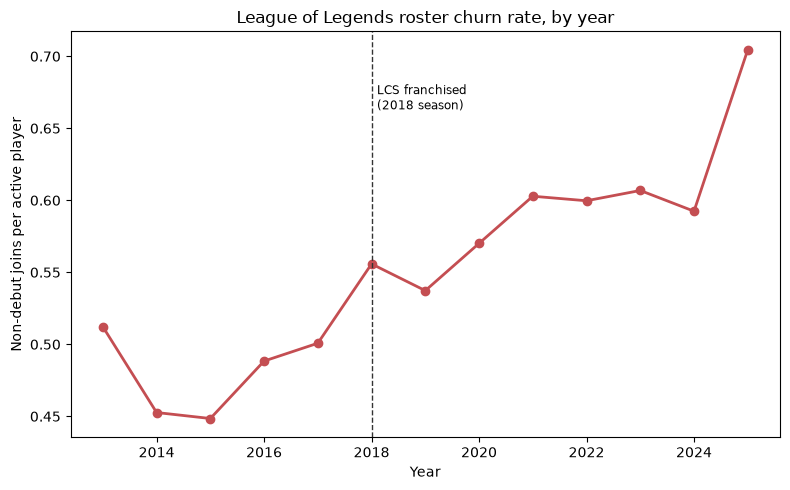

,join_year,transfers,active_players,churn_rate
86,2013,378.0,738.0,0.512
87,2014,454.0,1003.0,0.453
88,2015,592.0,1320.0,0.448
89,2016,903.0,1849.0,0.488
90,2017,1312.0,2620.0,0.501
91,2018,2046.0,3681.0,0.556
92,2019,2371.0,4413.0,0.537
93,2020,2790.0,4894.0,0.570
94,2021,3456.0,5733.0,0.603
95,2022,3751.0,6255.0,0.600


In [4]:
lol = churn[(churn["title_id"] == "league_of_legends") & (churn["join_year"] >= 2013) & (churn["join_year"] <= 2025)].sort_values("join_year")
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lol["join_year"], lol["churn_rate"], marker="o", color=colors["C0"], linewidth=2)
ax.axvline(2018, color="#333", linestyle="--", linewidth=1)
ax.text(2018.1, ax.get_ylim()[1]*0.95, "LCS franchised\n(2018 season)", fontsize=8.5, va="top")
ax.set_xlabel("Year")
ax.set_ylabel("Non-debut joins per active player")
ax.set_title("League of Legends roster churn rate, by year")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_churn_fig1_lol.png", dpi=150, bbox_inches="tight")
plt.show()
lol[["join_year", "transfers", "active_players", "churn_rate"]].round(3)

## Franchising test case 2: VALORANT (VCT Partnership franchised from 2023)

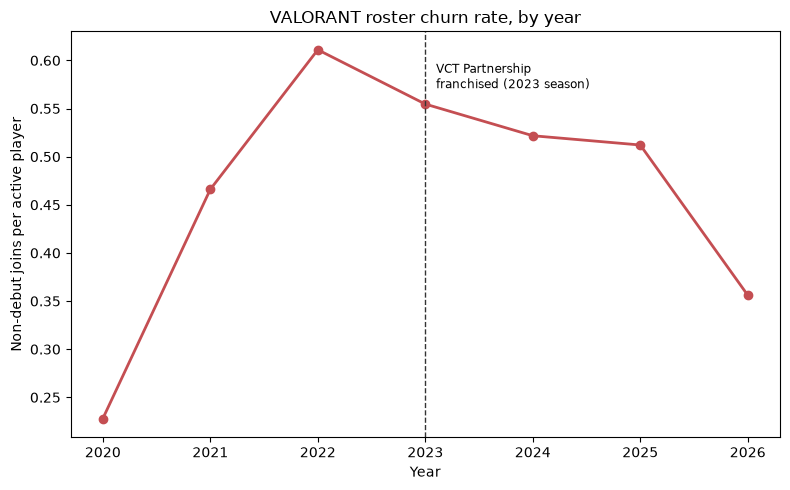

,join_year,transfers,active_players,churn_rate
210,2020,539.0,2364.0,0.228
211,2021,1774.0,3806.0,0.466
212,2022,2776.0,4543.0,0.611
213,2023,2797.0,5043.0,0.555
214,2024,2590.0,4964.0,0.522
215,2025,2323.0,4536.0,0.512
216,2026,1386.0,3892.0,0.356


In [5]:
val = churn[(churn["title_id"] == "valorant") & (churn["join_year"] >= 2020) & (churn["join_year"] <= 2026)].sort_values("join_year")
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(val["join_year"], val["churn_rate"], marker="o", color=colors["C0"], linewidth=2)
ax.axvline(2023, color="#333", linestyle="--", linewidth=1)
ax.text(2023.1, ax.get_ylim()[1]*0.95, "VCT Partnership\nfranchised (2023 season)", fontsize=8.5, va="top")
ax.set_xlabel("Year")
ax.set_ylabel("Non-debut joins per active player")
ax.set_title("VALORANT roster churn rate, by year")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_churn_fig2_valorant.png", dpi=150, bbox_inches="tight")
plt.show()
val[["join_year", "transfers", "active_players", "churn_rate"]].round(3)

### Read -- franchising test cases: a mixed result, not a clean confirmation

**League of Legends shows the opposite of the hypothesis: churn rose
after franchising, not fell.** Pre-franchising (2013-2017): churn rate
0.45-0.51, trending flat-to-slightly-up. Franchising year (2018): 0.556.
Every year since has been higher still -- 0.60-0.61 (2021-2023), peaking
at 0.705 in 2025. A franchised league with fixed, capital-intensive
franchise slots was supposed to (plausibly) stabilize rosters by raising
the cost of constant turnover; the data shows the reverse happened, at
least by this measure. Worth being direct about this rather than
quietly dropping the test case because it didn't confirm the hypothesis.

**VALORANT shows a gentler, partially-consistent pattern, but not a sharp
discontinuity at the franchising year either.** Churn rises steadily
from the circuit's first two years (2020: 0.228 -- almost certainly an
artifact of everyone being new that year, not a real low-churn signal --
2021: 0.466) to a peak of **0.611 in 2022, the year *before* franchising**,
then declines through the franchised era: 0.555 (2023) -> 0.522 (2024) ->
0.512 (2025) -> 0.356 (2026). **The 2026 figure should not be read as
continuing that decline** -- 2026 is a partial year as of this notebook's
run (2026-10-02), so its `active_players` denominator and `transfers`
numerator are both still accumulating; a declining rate in an incomplete
year is expected regardless of any real trend. Treating 2023-2025 as the
real post-franchising read: a real, if modest, decline from the 2022
peak -- but since the peak was the year *before* the transition, this
reads more like "churn was already turning over a cycle" than a clean
franchising-caused drop.

**Net: this specific hypothesis (franchising reduces churn) is not
supported cleanly by either test case.** VALORANT's trend is consistent
with it in direction but not in timing (peak precedes the transition);
League of Legends contradicts it outright. Two titles is too small a
sample to generalize from regardless -- worth revisiting if a third
franchised transition becomes trackable, not treated as settled either
way from this.

## Churn rate by community (pooled, 2019-2025 -- the window every community has real data for)

titles contributing per community, 2019-2025 window:
community
C0    8
C1    5
C2    4
Name: title_id, dtype: int64



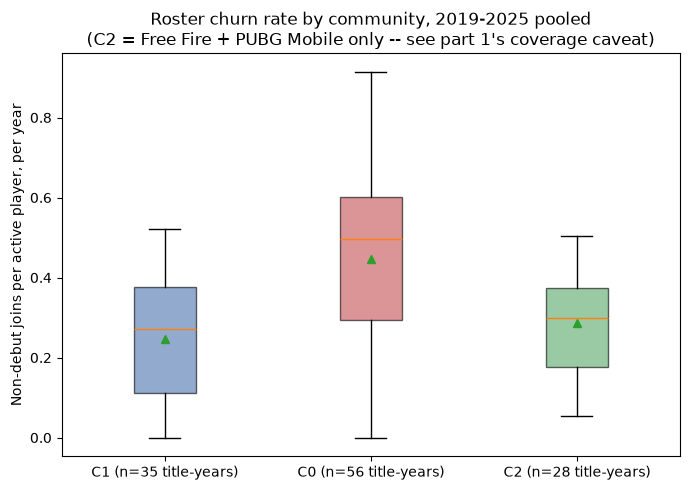

,count,mean,std,min,25%,50%,75%,max
community,,,,,,,,
C0,56.0,0.447,0.226,0.000,0.295,0.497,0.600,0.915
C1,35.0,0.246,0.159,0.000,0.112,0.272,0.377,0.522
C2,28.0,0.285,0.125,0.054,0.176,0.300,0.375,0.503


In [6]:
pooled = churn[(churn["join_year"] >= 2019) & (churn["join_year"] <= 2025)]
coverage = pooled.groupby("community")["title_id"].nunique()
print("titles contributing per community, 2019-2025 window:")
print(coverage)
print()

fig, ax = plt.subplots(figsize=(7, 5))
data = [pooled[pooled["community"] == c]["churn_rate"] for c in order]
bp = ax.boxplot(data, tick_labels=[f"{c} (n={len(d)} title-years)" for c, d in zip(order, data)], patch_artist=True, showmeans=True)
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(colors[c])
    patch.set_alpha(0.6)
ax.set_ylabel("Non-debut joins per active player, per year")
ax.set_title("Roster churn rate by community, 2019-2025 pooled\n(C2 = Free Fire + PUBG Mobile only -- see part 1's coverage caveat)")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_churn_fig3_by_community.png", dpi=150, bbox_inches="tight")
plt.show()

pooled.groupby("community")["churn_rate"].describe().round(3)

In [7]:
pooled.groupby("title")["churn_rate"].median().sort_values(ascending=False).round(3)

title
Rocket League                   0.735
Overwatch                       0.606
League of Legends               0.600
VALORANT                        0.512
Rainbow Six Siege               0.424
Apex Legends                    0.411
Dota 2                          0.399
Counter-Strike 2                0.376
PUBG Mobile                     0.368
Mobile Legends: Bang Bang       0.348
PUBG: BATTLEGROUNDS             0.284
Fortnite                        0.281
Free Fire                       0.271
League of Legends: Wild Rift    0.159
StarCraft II                    0.157
Teamfight Tactics               0.047
Hearthstone                     0.000
Name: churn_rate, dtype: float64

### Read -- churn is where C0 actually gets a distinctive profile

**C0 has by far the highest roster churn of the three communities; C1
has the lowest.** Pooled 2019-2025: C0 median 0.497, C2 median 0.300, C1
median 0.272 -- C0's own 25th percentile (0.295) sits above C1's median.
This is a real finding in its own right: parts 1 and 2 of this thread
(debut age, career length) found **C0 has no standout profile** on
either axis, sitting in the unremarkable middle. **Churn is the one
measure where C0 is clearly distinctive** -- the highest-instability
community, not a neutral one. C1's low churn is consistent with, and
adds a third independent axis to, its "veteran, dedicated" story from
part 1 (oldest debut age, longest careers, and now also the most stable
rosters).

**Two near-zero outliers are very likely a measurement artifact, not a
real loyalty signal, and worth excluding from how the community-level
read is weighted**: Hearthstone (C1) and Teamfight Tactics (C0) both sit
at or near 0.000 churn. Both are competitive formats built around
individual competitors more than fixed 5-player rosters the traditional
team-based titles have -- a "squad" entry for sponsorship purposes isn't
the same thing as League of Legends' or Counter-Strike's actual team
structure, so near-zero churn here most likely reflects the metric not
applying cleanly to this format, not genuine player-team loyalty.
**Recomputing C0's median with Teamfight Tactics excluded raises it to
0.512** (7 remaining titles) -- the community's high-churn character is
not an artifact of including a mistaken zero; if anything it's being
mildly understated by TFT's inclusion. The same exclusion would raise
C1's floor too, but C1 has no comparably high title pulling the other
way, so its low-churn character holds either way.

**Per-title, Rocket League (0.735) and Overwatch (0.606) anchor C0's high
end; StarCraft II (0.157) anchors C1's low end** (Hearthstone's 0.000
aside). Mobile titles (PUBG Mobile 0.368, Mobile Legends 0.348, Wild
Rift 0.159 -- the latter two landed in the LPDB sync since part 1's run,
C2 is now 4 of 5 titles covered, missing only Brawl Stars) sit in a
middle band, consistent with C2's intermediate position on the earlier
debut-age/career-length axes too.

## Caveats

- **A "year" here is the team's own roster-join calendar year**, not a
  season boundary -- some titles' competitive seasons don't align to the
  calendar (e.g. split seasons spanning a year boundary), which could
  smear a sharp in-season churn spike across two adjacent calendar years.
  Not corrected for here.
- **The "active players" denominator assumes a player with an open
  final stint is active through 2026-10-02** (today, for this run) --
  reasonable for recent years, increasingly an overcount for a player
  whose LPDB page is simply stale/unmaintained rather than genuinely
  still active. Affects older years less (more of those players have a
  real recorded `leave_date` by now).
- **C2's community-level numbers are still the 2-of-5-titles preview**
  from part 1 (Free Fire, PUBG Mobile only) -- same caveat carries over
  unchanged.
- **C3 excluded entirely**, same reason as part 1.
- **A roster move isn't always a player's own choice** (releases, team
  folding, org restructuring all produce the same join/leave pattern as
  a voluntary transfer) -- this notebook measures roster *instability*,
  not player agency or team quality, and that distinction matters for
  how "churn" should be read.